# Consolidated figures — sym_pt (Liu-extension)
Reported values/stars read from `stats_results.csv`. Run top to bottom.

**Two cells need prerequisite code pasted above them** (marked) — the stacked-WTA and Procrustes cells depend on `wta_data`/`TFCE_DIR` and `subj_mats`/`stratum`/`coords`/`HEMIS`/`df` respectively, which aren't in this notebook yet.

## 1. Setup & paths

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
STATS_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results_harmonized_corrected.csv')
UNIVAR_HARM = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized.csv')
RSA_HARM    = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CATEGORIES = ['face', 'house', 'object', 'word']

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')

LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact


## 2. Load data — `ctrl_le`, `pt_le`, `ctrl_subs`, `otc_subs`

In [3]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls -> first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients -> last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())
print(f'Controls: {len(ctrl_subs)}   OTC patients: {len(otc_subs)}')

Controls: 38   OTC patients: 22


In [4]:
# Harmonized per-measure frames for the sum-sel & distinctiveness panels.
# Same exclusion + session rule as the cell above (controls=first, OTC=last).
# sum-selectivity -> univariate_v1_harmonized (sum_selec_norm)
# distinctiveness -> rsa_v1_harmonized       (liu_distinctiveness)
def _load_harmonized(path):
    d = pd.read_csv(path)
    d = d[~d['subject_id'].isin(EXCLUDE)]
    d['ses_num'] = pd.to_numeric(d['session'], errors='coerce').astype(int)
    for bad_sub, bad_ses in EXCLUDE_SES:
        d = d[~((d['subject_id'] == bad_sub) & (d['ses_num'] == bad_ses))]
    if 'pair' in d.columns:                      # rsa is long by pair; collapse
        d = d.drop(columns=['pair', 'fisher_r']).drop_duplicates()
    ctrl = d[d['status'] == 'control']
    fs = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
    ctrl = ctrl.merge(fs, on='subject_id'); ctrl = ctrl[ctrl['ses_num'] == ctrl['keep']].drop(columns='keep')
    pt = d[d['group'] == 'OTC']
    ls = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
    pt = pt.merge(ls, on='subject_id'); pt = pt[pt['ses_num'] == pt['keep']].drop(columns='keep')
    return ctrl, pt

ctrl_uni, pt_uni = _load_harmonized(UNIVAR_HARM)   # sum_selec_norm
ctrl_rsa, pt_rsa = _load_harmonized(RSA_HARM)      # liu_distinctiveness
print(f'univar harmonized: {ctrl_uni.subject_id.nunique()} ctrl / {pt_uni.subject_id.nunique()} OTC')
print(f'rsa    harmonized: {ctrl_rsa.subject_id.nunique()} ctrl / {pt_rsa.subject_id.nunique()} OTC')

univar harmonized: 38 ctrl / 22 OTC
rsa    harmonized: 38 ctrl / 22 OTC


## 3. Peak coordinates (MNI) — Fig 4
Reads `peak_coords_mni.csv`. House parcel = `house_PPA_strict` here (intentional for peak).

In [5]:
# 3a. MNI peak-coord machinery (prereq for 3b)
from matplotlib.patches import Ellipse
import matplotlib.transforms as mtransforms

MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)

mni = pd.read_csv(MNI_CSV)
mni = mni[~mni['subject_id'].isin(EXCLUDE)]
mni['ses_num'] = pd.to_numeric(mni['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni['subject_id'] == bad_sub) & (mni['ses_num'] == bad_ses))]

ctrl = mni[mni['status'] == 'control'].copy()
_fs  = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'k'})
ctrl = ctrl.merge(_fs, on='subject_id'); ctrl = ctrl[ctrl['ses_num'] == ctrl['k']].drop(columns='k')
pt   = mni[mni['group'] == 'OTC'].copy()
_ls  = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'k'})
pt   = pt.merge(_ls, on='subject_id'); pt = pt[pt['ses_num'] == pt['k']].drop(columns='k')

ctrl_subs_mni = sorted(ctrl['subject_id'].unique())
pt_subs_mni   = sorted(pt['subject_id'].unique())

def coords(df, sub, roi, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == h)]
    if len(m) == 0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)

def intact(sub):
    m = pt[pt['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')

xlim = (-80, 80); ylim = (-100, 0)
lx = ctrl[ctrl['hemi'] == 'l']['peak_x_mni'].mean()
rx = ctrl[ctrl['hemi'] == 'r']['peak_x_mni'].mean()
midline = (lx + rx) / 2

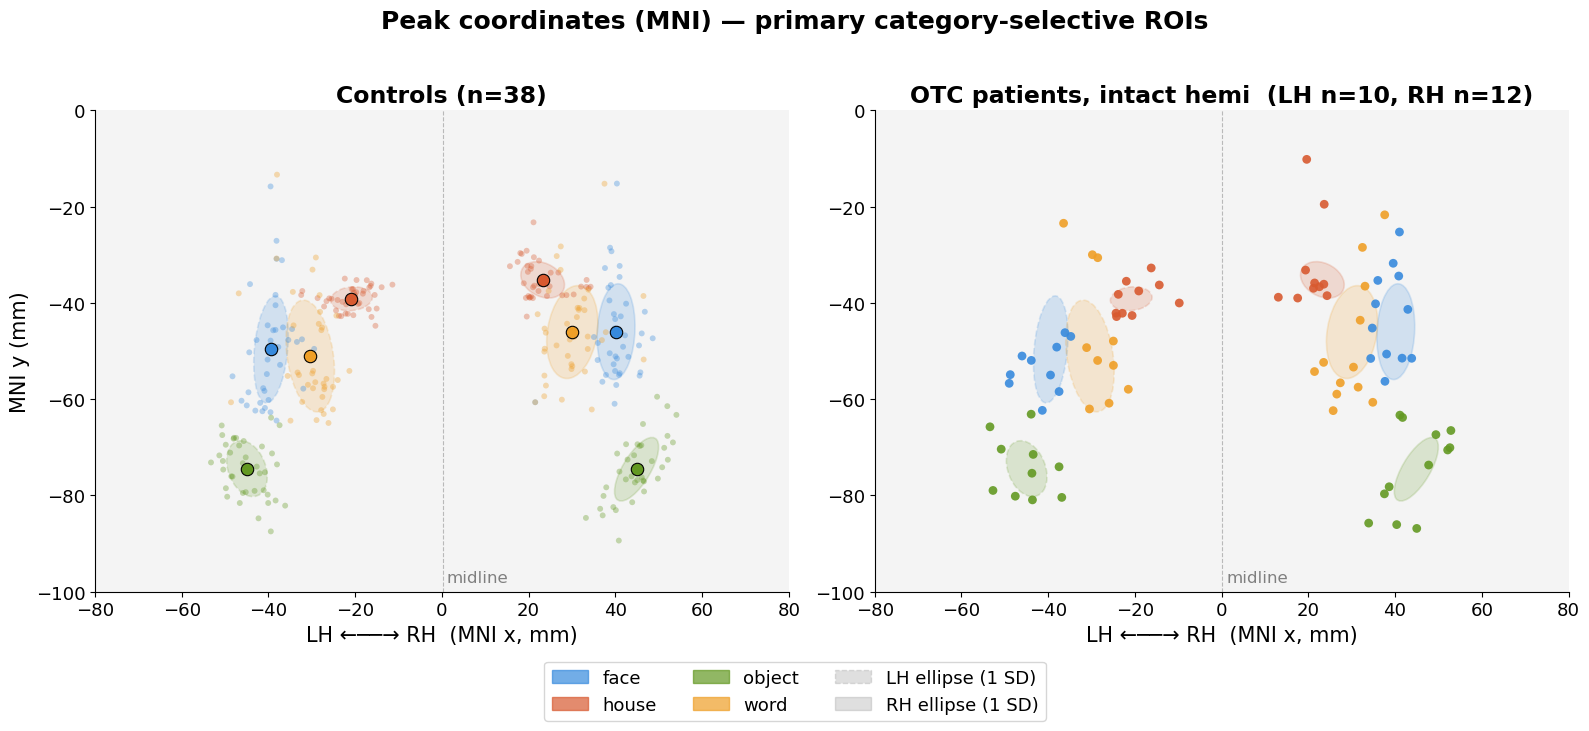

In [6]:
# 3b. Peak coords plot — primary ROIs
CATS_PRIMARY = [
    ('face_FFA',         '#378ADD', 'face'),
    ('house_PPA_strict', '#D85A30', 'house'),
    ('object_LOC',       '#639922', 'object'),
    ('word_VWFA',        '#EF9F27', 'word'),
]
n_lh = sum(1 for s in pt_subs_mni if intact(s) == 'l')
n_rh = sum(1 for s in pt_subs_mni if intact(s) == 'r')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80, edgecolors='black',
                           linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40, edgecolors='none', alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=12, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←──→ RH  (MNI x, mm)', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=15)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=17, fontweight='bold')
    else:
        ax.set_title(f'OTC patients, intact hemi  (LH n={n_lh}, RH n={n_rh})',
                     fontsize=17, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)')]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. WTA composition bars (LH-/RH-intact) — q-stars from `stats_results.csv`

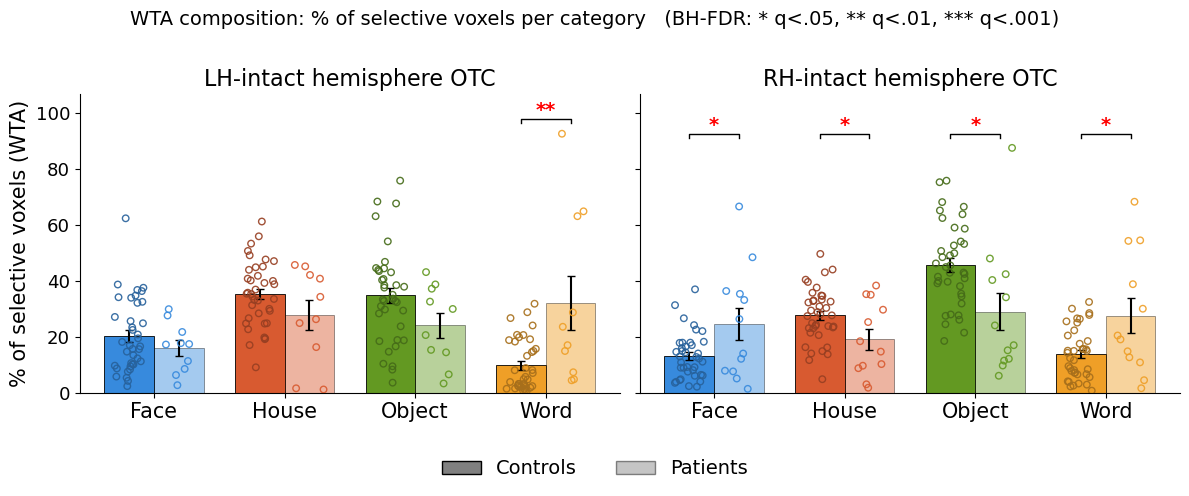

In [7]:
import matplotlib.colors as mcolors

WTA_CSV = '/user_data/csimmon2/sym_pt/group_results/wta_percentages.csv'
MODEL_FOR_HEMI = {'l': 'M1_LH_ctrl_vs_pt', 'r': 'M2_RH_ctrl_vs_pt'}

def darken(c, f=0.70):
    r, g, b = mcolors.to_rgb(c)
    return (r*f, g*f, b*f)

def _stars(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

wta = pd.read_csv(WTA_CSV)
wta = wta[(wta['region'] == 'otc') & (wta['denominator'] == 'selective')].copy()
wta = wta[~wta['subject_id'].isin(EXCLUDE)]
wta['ses_num'] = pd.to_numeric(wta['session'], errors='coerce').astype('Int64')
for s, se in EXCLUDE_SES:
    wta = wta[~((wta['subject_id'] == s) & (wta['ses_num'] == se))]
_c = wta[wta['status'] == 'control']
_c = _c.merge(_c.groupby('subject_id')['ses_num'].min().rename('k').reset_index(), on='subject_id')
_c = _c[_c['ses_num'] == _c['k']].drop(columns='k')
_p = wta[wta['group'] == 'OTC']
_p = _p.merge(_p.groupby('subject_id')['ses_num'].max().rename('k').reset_index(), on='subject_id')
_p = _p[_p['ses_num'] == _p['k']].drop(columns='k')
wta = pd.concat([_c, _p], ignore_index=True)

stats = pd.read_csv(STATS_CSV)
sw = stats[(stats['measure'] == 'wta') & (stats['comparison'] == 'patient_vs_control')]
qmap = {}
for hemi, model in MODEL_FOR_HEMI.items():
    for _, r in sw[sw['model'] == model].iterrows():
        qmap[(hemi, r['level'])] = r['q_fdr']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(CATEGORIES)); w = 0.38
RNG = np.random.RandomState(0)
for ax, h, hlabel in zip(axes, ['l', 'r'], ['LH-intact', 'RH-intact']):
    sub = wta[wta['hemi'] == h]
    max_top = 0
    for offset, grp, alpha in [(-w/2, 'control', 1.0), (+w/2, 'OTC', 0.45)]:
        means, sems = [], []
        for c in CATEGORIES:
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct']
            means.append(vals.mean()); sems.append(vals.sem())
        ax.bar(x + offset, means, w, yerr=sems, color=[CAT_COLORS[c] for c in CATEGORIES],
               alpha=alpha, edgecolor='black', linewidth=0.6, capsize=3, zorder=2)
        for xi, c in enumerate(CATEGORIES):
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct'].values
            ecol = darken(CAT_COLORS[c]) if grp == 'control' else CAT_COLORS[c]
            jit = (RNG.rand(len(vals)) - 0.5) * (w * 0.6)
            ax.scatter(xi + offset + jit, vals, s=22, facecolors='none',
                       edgecolors=ecol, linewidths=1.0, alpha=0.9, zorder=3)
            if len(vals): max_top = max(max_top, vals.max())
    by, bh = max_top * 1.04, max_top * 0.015
    for xi, c in enumerate(CATEGORIES):
        s = _stars(qmap.get((h, c), np.nan))
        if not s: continue
        xl, xr = xi - w/2, xi + w/2
        ax.plot([xl, xl, xr, xr], [by, by+bh, by+bh, by], color='black', lw=1, zorder=4)
        ax.text(xi, by+bh, s, ha='center', va='bottom', color='red',
                fontsize=14, fontweight='bold', zorder=4)
    ax.set_ylim(0, max_top * 1.22)
    ax.set_xticks(x); ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=15)
    ax.set_title(f'{hlabel} hemisphere OTC', fontsize=16)
    if h == 'l':
        ax.set_ylabel('% of selective voxels (WTA)', fontsize=15)
    ax.tick_params(axis='y', labelsize=13)
fig.legend(handles=[Patch(facecolor='gray', edgecolor='black', label='Controls'),
                    Patch(facecolor='gray', alpha=0.45, edgecolor='black', label='Patients')],
           ncol=2, frameon=False, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, -0.1))
fig.suptitle('WTA composition: % of selective voxels per category   '
             '(BH-FDR: * q<.05, ** q<.01, *** q<.001)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig(FIG_DIR / 'wta_composition_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Sensitivity check (NOT a replacement for reported q): closure-aware CLR re-test
from scipy.stats import mannwhitneyu
EPS = 0.5  # % pseudocount so zero-share categories can be logged

def clr_by_subject(df_h):
    out = {}
    for sid, g in df_h.groupby('subject_id'):
        comp = np.array([g[g['category'] == c]['wta_pct'].mean() for c in CATEGORIES], float)
        comp = np.nan_to_num(comp, nan=0.0) + EPS
        lg = np.log(comp)
        out[sid] = lg - lg.mean()          # CLR
    return out

print(f"{'hemi':<5}{'category':<9}{'FDR (raw %)':<13}{'CLR p (MW, unc.)':<16}")
for h in ('l', 'r'):
    sub = wta[wta['hemi'] == h]
    Cc = np.array(list(clr_by_subject(sub[sub['group'] == 'control']).values()))
    Cp = np.array(list(clr_by_subject(sub[sub['group'] == 'OTC']).values()))
    for i, c in enumerate(CATEGORIES):
        _, p = mannwhitneyu(Cc[:, i], Cp[:, i], alternative='two-sided')
        raw = _stars(qmap.get((h, c), np.nan)) or 'ns'
        print(f"{h:<5}{c:<9}{raw:<13}{p:<16.3f}")

hemi category FDR (raw %)  CLR p (MW, unc.)
l    face     ns           0.454           
l    house    ns           0.052           
l    object   ns           0.059           
l    word     **           0.010           
r    face     *            0.156           
r    house    *            0.052           
r    object   *            0.006           
r    word     *            0.040           


## 5. Sum-selectivity & distinctiveness (shared style)
Box/violin toggle via `PLOT_KIND`. Controls = solid category color, patients = translucent. q read from `stats_results.csv`.

In [9]:
PLOT_KIND = 'box'   # 'box' or 'violin'
CTRL_A, PT_A = 0.9, 0.3            # control solid, patient translucent
CAT_PRIMARY = {'face': 'face_FFA', 'house': 'house_PPA',
               'object': 'object_LOC', 'word': 'word_VWFA'}
CATS_PANEL = ['face', 'house', 'object', 'word']
_stats_df = pd.read_csv(STATS_CSV)

def stars_from_q(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

def q_for(measure, cat, h):
    m = _stats_df[(_stats_df['measure'] == measure) &
                  (_stats_df['comparison'] == 'patient_vs_control') &
                  (_stats_df['level'] == CAT_PRIMARY[cat]) & (_stats_df['hemi'] == h)]
    return float(m['q_fdr'].iloc[0]) if len(m) else np.nan

def draw_dist(ax, vals, pos, col, alpha, width=0.5):
    if len(vals) < 2: return
    if PLOT_KIND == 'violin':
        parts = ax.violinplot([vals], positions=[pos], widths=width,
                              showmeans=False, showmedians=False, showextrema=False)
        for b in parts['bodies']:
            b.set_facecolor(col); b.set_alpha(alpha); b.set_edgecolor(col)
    else:
        bp = ax.boxplot([vals], positions=[pos], widths=width, patch_artist=True,
                        showfliers=False, manage_ticks=False, zorder=2)
        for box in bp['boxes']:
            box.set_facecolor(col); box.set_alpha(alpha); box.set_edgecolor(col)
        for el in ('whiskers', 'caps'):
            for ln in bp[el]:
                ln.set_color(col)
        for ln in bp['medians']:
            ln.set_color('black')

def build_primary_table(df, subjects, value_col, log10=False):
    rows = []
    for s in subjects:
        for cat in CAT_PRIMARY:
            for h in ('l', 'r'):
                m = df[(df['subject_id'] == s) & (df['category'] == CAT_PRIMARY[cat]) &
                       (df['hemi'] == h)].drop_duplicates(subset=['subject_id', 'category', 'hemi'])
                v = m[value_col].dropna().values
                if log10:
                    v = v[v > 0]
                    val = np.mean(np.log10(v)) if len(v) else np.nan
                else:
                    val = np.mean(v) if len(v) else np.nan
                if not np.isnan(val):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': val})
    return pd.DataFrame(rows)

def plot_primary_panel(measure, value_col, ylabel, fname, suptitle,
                       log10=False, y0=None, ctrl_df=None, pt_df=None):
    ctrl_df = ctrl_le if ctrl_df is None else ctrl_df
    pt_df   = pt_le   if pt_df   is None else pt_df
    ctrl_subjects = sorted(ctrl_df['subject_id'].unique())
    pt_subjects   = sorted(pt_df['subject_id'].unique())
    ctrl_t = build_primary_table(ctrl_df, ctrl_subjects, value_col, log10)
    pt_t   = build_primary_table(pt_df,   pt_subjects,   value_col, log10)
    intact_lookup = dict(zip(pt_df['subject_id'], pt_df['intact_hemi']))
    pt_t['intact_hemi'] = pt_t['subject_id'].map(intact_lookup)
    pt_t = pt_t[((pt_t['intact_hemi'] == 'left') & (pt_t['hemi'] == 'l')) |
                ((pt_t['intact_hemi'] == 'right') & (pt_t['hemi'] == 'r'))]

    INTRA, INTER, CAT_GAP = 0.55, 0.7, 1.0
    pos_w = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]; cat_width = pos_w[-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    rng = np.random.RandomState(42); cat_centers = []
    allv = np.concatenate([ctrl_t['val'].dropna().values, pt_t['val'].dropna().values])
    gmax, gmin = np.nanmax(allv), np.nanmin(allv); brack_h = (gmax - gmin) * 0.02
    for ci, cat in enumerate(CATS_PANEL):
        col = CAT_COLORS[cat]; base = ci * (cat_width + CAT_GAP)
        positions = [base + p for p in pos_w]; cat_centers.append(np.mean(positions))
        cl = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'l')]['val'].values
        cr = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'r')]['val'].values
        pl = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'l')]['val'].values
        pr = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'r')]['val'].values
        for vals, p, a in [(cl, positions[0], CTRL_A), (pl, positions[1], PT_A),
                           (cr, positions[2], CTRL_A), (pr, positions[3], PT_A)]:
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0: continue
            draw_dist(ax, vals, p, col, a)
            jit = rng.uniform(-0.09, 0.09, len(vals))
            ax.scatter(np.full(len(vals), p) + jit, vals, facecolors=col, alpha=0.7,
                       s=18, edgecolors='black', linewidths=0.4, zorder=3)
        for (h, x_l, x_r) in [('l', positions[0], positions[1]), ('r', positions[2], positions[3])]:
            s = stars_from_q(q_for(measure, cat, h))
            if not s: continue
            by = gmax + brack_h * 2
            ax.plot([x_l, x_l, x_r, x_r], [by, by+brack_h, by+brack_h, by],
                    color='black', lw=1, zorder=6)
            ax.text((x_l + x_r) / 2, by + brack_h, s, ha='center', va='bottom',
                    color='red', fontsize=13, fontweight='bold', zorder=6)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=14); ax.tick_params(axis='y', labelsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for cat, center in zip(CATS_PANEL, cat_centers):
        ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
                color=CAT_COLORS[cat], ha='center', va='top',
                transform=ax.get_xaxis_transform())
    tw = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
    ax.set_xlim(-0.35, tw + 0.35); ax.margins(x=0.005)
    yr = gmax - gmin
    lo = y0 if y0 is not None else gmin - 0.04 * yr
    ax.set_ylim(lo, gmax + 0.14 * yr)
    ax.legend(handles=[Patch(facecolor='gray', alpha=CTRL_A, label='Control'),
                       Patch(facecolor='gray', alpha=PT_A, label='Patient (intact hemi)')],
              loc='upper right', fontsize=11, frameon=True, framealpha=0.9)
    plt.suptitle(suptitle, fontsize=13, fontweight='bold', y=0.99)
    plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

### 5a. Sum-selectivity (log10)

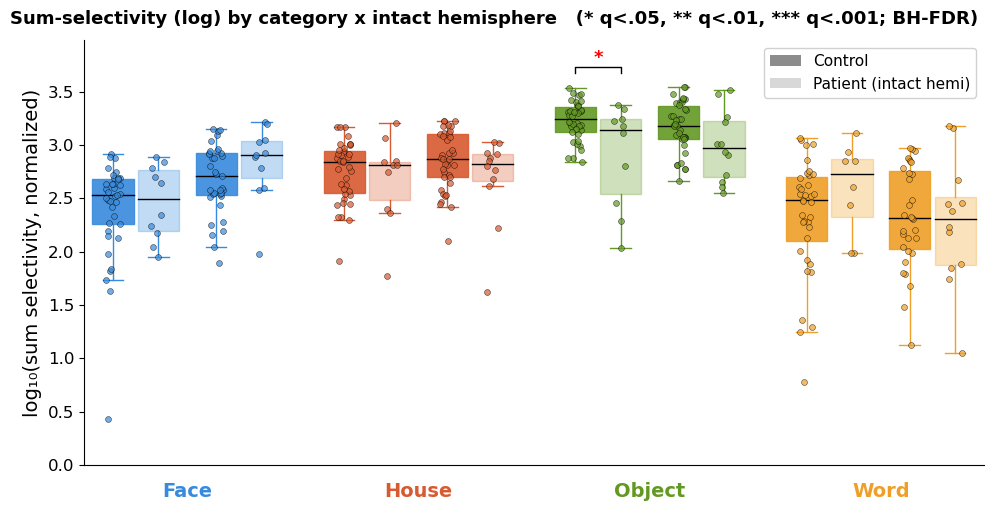

In [10]:
plot_primary_panel(
    measure='sum_selectivity', value_col='sum_selec_norm',
    ylabel='log₁₀(sum selectivity, normalized)',
    fname='sum_selectivity_primary.png',
    suptitle='Sum-selectivity (log) by category x intact hemisphere   '
             '(* q<.05, ** q<.01, *** q<.001; BH-FDR)',
    log10=True, y0=0.0, ctrl_df=ctrl_uni, pt_df=pt_uni)

### 5b. Distinctiveness (harmonized: rVWFA q=.034 → surviving star)

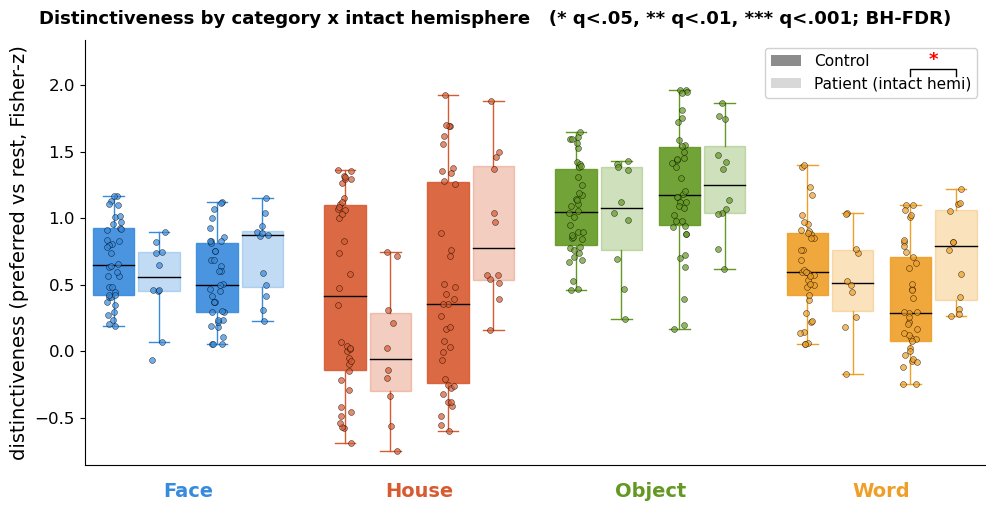

In [11]:
plot_primary_panel(
    measure='distinctiveness', value_col='liu_distinctiveness',
    ylabel='distinctiveness (preferred vs rest, Fisher-z)',
    fname='distinctiveness_primary.png',
    suptitle='Distinctiveness by category x intact hemisphere   '
             '(* q<.05, ** q<.01, *** q<.001; BH-FDR)',
    log10=False, ctrl_df=ctrl_rsa, pt_df=pt_rsa)

## 6. WTA within-cluster composition (stacked)
Prereq cells (TFCE paths + `wta_data` builder) are included just below.

In [12]:
# ─── TFCE paths (prereq for stacked WTA) ─────────────────────────────────
import nibabel as nib
TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc_fdr'
print('TFCE_DIR:', TFCE_DIR, '| exists:', TFCE_DIR.exists())

TFCE_DIR: /user_data/csimmon2/sym_pt/group_results/tfce_votc_fdr | exists: True


In [13]:
# ─── WTA computation (Liu contrasts, per subject × hemi) ─────────────────
# Recomputes wta_data using SAME VOTC masks as tfce_votc_contrasts.py
# (loaded from TFCE_DIR/votc_{l,r}_mask.nii.gz) to ensure hemi labels
# match TFCE cluster files.

import os
from sym_pt_params import (skip_subs, get_sessions, is_patient,
                            get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word'] # note liu contrasts are all cat-vs-others, so same winner code (1) for all categories, not actual liu contrasts.
LIU_CONTRASTS = {'face': (6, False), 'house': (7, False),
                 'object': (8, False), 'word': (9, False)}
WTA_THRESHOLD = 2.326
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

# ── Load VOTC masks (same as TFCE script used) ───────────────────────
_lh_img = nib.load(TFCE_DIR / 'votc_l_mask.nii.gz')
VOTC_MASK_LH = _lh_img.get_fdata() > 0.5
VOTC_MASK_RH = nib.load(TFCE_DIR / 'votc_r_mask.nii.gz').get_fdata() > 0.5
MNI_AFFINE = _lh_img.affine
MNI_SHAPE  = _lh_img.shape
print(f'LH VOTC: {VOTC_MASK_LH.sum():,} | RH VOTC: {VOTC_MASK_RH.sum():,}')

# ── Subject loader ────────────────────────────────────────────────────
def load_subjects_xs():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        if f"{group}{sc}" in EXTRA_SKIP or sid in EXTRA_SKIP or group == 'nonOTC':
            continue
        post_sessions = [f'{s:02d}' for s in sessions
                         if f'{s:02d}' not in PRE_SURGERY_SESSIONS.get(sid, set())]
        if not post_sessions:
            continue
        subjects[sid] = {
            'session': post_sessions[0], 'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

# ── Compute WTA per subject × hemi ────────────────────────────────────
def _load_liu_zstats(sid, ses):
    vols = {}
    for cat, (cope, neg) in LIU_CONTRASTS.items():
        p = os.path.join(processed_dir, sid, f'ses-{ses}', 'derivatives', 'fsl',
                         'loc', 'HighLevel.gfeat', f'cope{cope}.feat', 'stats',
                         'zstat1_mni.nii.gz')
        if not os.path.exists(p):
            return None
        d = nib.load(p).get_fdata()
        vols[cat] = -d if neg else d
    return vols

def _compute_wta(vols, mask):
    z = np.stack([vols[c][mask] for c in CATEGORIES], axis=-1)
    max_z = z.max(axis=-1)
    winner = z.argmax(axis=-1) + 1
    winner[max_z < WTA_THRESHOLD] = 0
    sorted_z = np.sort(z, axis=-1)
    margin = sorted_z[:, -1] - sorted_z[:, -2]
    return winner, margin

subjects = load_subjects_xs()
ctrl_n = sum(1 for i in subjects.values() if i['group'] == 'control')
otc_n  = sum(1 for i in subjects.values() if i['group'] == 'OTC')
print(f'Subjects: {ctrl_n} ctrl + {otc_n} OTC')

wta_data, skipped = {}, []
for sid, info in subjects.items():
    vols = _load_liu_zstats(sid, info['session'])
    if vols is None:
        skipped.append(sid); continue
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
        winner, margin = _compute_wta(vols, mask)
        wta_data[(sid, h)] = {
            'winner': winner, 'margin': margin,
            'n_voxels': int(mask.sum()),
            'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
        }
print(f'WTA: {len(wta_data)} sub-hemi entries' + (f' | skipped: {skipped}' if skipped else ''))

LH VOTC: 11,340 | RH VOTC: 11,540
Subjects: 38 ctrl + 25 OTC
WTA: 98 sub-hemi entries | skipped: ['sub-098', 'sub-101', 'sub-109']


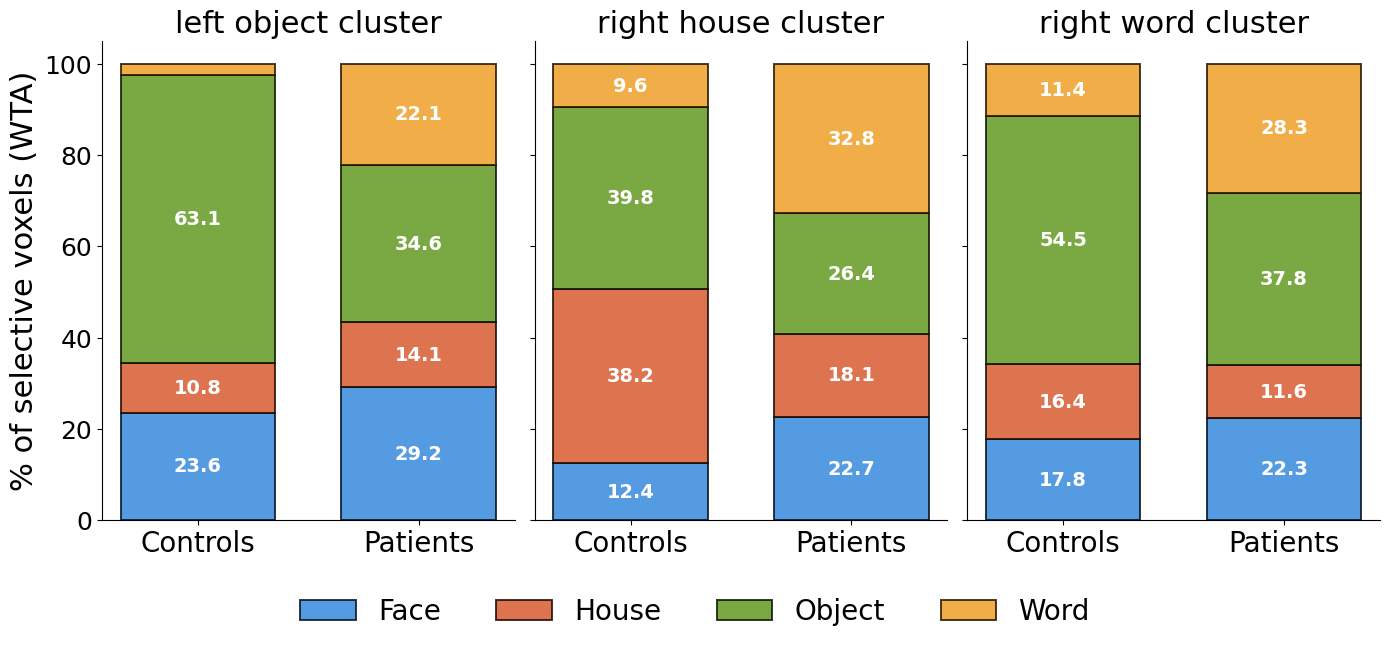

In [14]:
# ─── WTA composition bars (Liu-style, per cluster) ──────────────────────
# Composition normalized to selective voxels only.
import colorsys
BAR_ALPHA      = 0.85
EDGE_LINEWIDTH = 1.4
DARKEN_FACTOR  = 0.15
CLUSTERS = [
    ('object', 'l', 1, 'left object cluster'),
    ('house',  'r', 1, 'right house cluster'),
    ('word',   'r', 2, 'right word cluster'),
]

def darken_hls(hex_color, factor=DARKEN_FACTOR):
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(hex_color))
    return colorsys.hls_to_rgb(h, l * factor, s)

def composition_at_mask(group_label, hemi, cluster_3d_mask, hemi_3d_mask):
    cluster_in_hemi = cluster_3d_mask[hemi_3d_mask]
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, hh), d in wta_data.items():
        if hh != hemi or d['group'] != group_label:
            continue
        if len(d['winner']) != len(cluster_in_hemi):
            continue
        w = d['winner'][cluster_in_hemi]
        n = (w > 0).sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            per_cat[cat].append(100 * (w == i).sum() / n if n else np.nan)
    return {c: np.array(v) for c, v in per_cat.items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), sharey=True)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTERS):
    cluster_3d = nib.load(TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl' /
                          f'rand_tfce_corrp_tstat{tstat}.nii.gz').get_fdata() > 0.95
    hemi_3d    = nib.load(TFCE_DIR / f'votc_{hemi}_mask.nii.gz').get_fdata() > 0.5
    ctrl_comp = composition_at_mask('control', hemi, cluster_3d, hemi_3d)
    pt_comp   = composition_at_mask('OTC',     hemi, cluster_3d, hemi_3d)
    for xi, comp in zip([0, 1], [ctrl_comp, pt_comp]):
        bottom = 0
        for c in CATEGORIES:
            h = np.nanmean(comp[c])
            ax.bar(xi, h, bottom=bottom, width=0.7, facecolor=CAT_COLORS[c], alpha=BAR_ALPHA,
                   edgecolor=darken_hls(CAT_COLORS[c]), linewidth=EDGE_LINEWIDTH)
            if h >= 3:
                ax.text(xi, bottom + h/2, f'{h:.1f}', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold')
            bottom += h
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Controls', 'Patients'], fontsize=20)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 105); ax.set_title(title, fontsize=22)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[0].set_ylabel('% of selective voxels (WTA)', fontsize=22)
handles = [Patch(facecolor=CAT_COLORS[c], alpha=BAR_ALPHA, edgecolor=darken_hls(CAT_COLORS[c]),
                 linewidth=EDGE_LINEWIDTH, label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=20,
           loc='lower center', bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.savefig(FIG_DIR / 'wta_within_cluster_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Procrustes / MDS configuration (geometry)
Prereq cells (RSA imports, `df`, helpers) are included just below. Note: this redefines `coords` for RSA — run after the peak cells.

In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.spatial import procrustes
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

sys.path.insert(0, "/user_data/csimmon2/git_repos/sym_pt")
from sym_pt_params import processed_dir

np.random.seed(0)
MNI_CSV     = Path(processed_dir) / "group_results" / "peak_coords" / "peak_coords_mni.csv"
ROIS        = ["face_FFA", "house_PPA", "object_LOC", "word_VWFA"]
CATS4       = ["face", "object", "house", "word"]
N_PERM      = 10_000
HEMIS       = {"l": "left", "r": "right"}
EXCLUDE     = ["sub-017"]
EXCLUDE_SES = [("sub-108", 2)]

In [16]:
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni["subject_id"].isin(EXCLUDE)].copy()
mni["ses_num"] = pd.to_numeric(mni["session"], errors="coerce").astype("Int64")
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni["subject_id"] == bad_sub) & (mni["ses_num"] == bad_ses))]
mni = mni[mni["category"].isin(ROIS) & mni["pair"].notna()].copy()

ls = (mni[mni["group"]=="OTC"].groupby("subject_id")["ses_num"].max()
        .reset_index().rename(columns={"ses_num":"keep"}))
pt = mni[mni["group"]=="OTC"].merge(ls, on="subject_id"); pt = pt[pt["ses_num"]==pt["keep"]].drop(columns="keep")
fs = (mni[mni["status"]=="control"].groupby("subject_id")["ses_num"].min()
        .reset_index().rename(columns={"ses_num":"keep"}))
ct = mni[mni["status"]=="control"].merge(fs, on="subject_id"); ct = ct[ct["ses_num"]==ct["keep"]].drop(columns="keep")
df = pd.concat([pt, ct], ignore_index=True)

df["pair_sorted"] = df["pair"].apply(lambda p: "-".join(sorted(p.split("-"))))
PAIRS_SORTED = sorted(df["pair_sorted"].unique())
assert len(PAIRS_SORTED) == 6, f"expected 6 pairs, got {PAIRS_SORTED}"
df = df.drop(columns=["pair"])
df["is_pt"] = (df["status"] == "patient").astype(int)

print("patients:", df[df.is_pt==1]["subject_id"].nunique(), "| controls:", df[df.is_pt==0]["subject_id"].nunique())
print(df.groupby(["category","hemi","status"])["subject_id"].nunique().unstack(fill_value=0))

patients: 22 | controls: 38
status           control  patient
category   hemi                  
face_FFA   l          38       10
           r          38       12
house_PPA  l          38       10
           r          38       12
object_LOC l          38       10
           r          38       12
word_VWFA  l          38       10
           r          38       12


In [17]:
def stratum(df, roi, hemi):
    s = df[(df["category"] == roi) & (df["hemi"] == hemi)].copy()
    s["group"] = np.where(s["is_pt"] == 1, "patient", "control")
    return s

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return np.nan if sp == 0 else (np.mean(x) - np.mean(y)) / sp

def perm_test(x, y, n=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    obs = np.mean(x) - np.mean(y)
    pool = np.concatenate([x, y]); nx = len(x)
    null = np.empty(n)
    for i in range(n):
        rng.shuffle(pool); null[i] = np.mean(pool[:nx]) - np.mean(pool[nx:])
    return obs, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n + 1)

def bh_fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 1.0
    for k in range(m-1, -1, -1):
        i = order[k]; run = min(run, p[i] * m / (k+1)); adj[i] = run
    return adj

def subj_rdm(sub_rows):
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row["pair_sorted"].split("-"); i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row["fisher_r"])
    return M

def coords(sim_mat):
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity="precomputed", random_state=0
               ).fit_transform(1.0 - M)

def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s.group == grp].groupby("subject_id")
            if g["pair_sorted"].nunique() == 6}

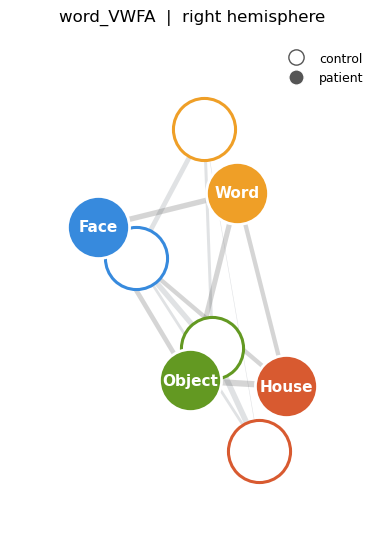

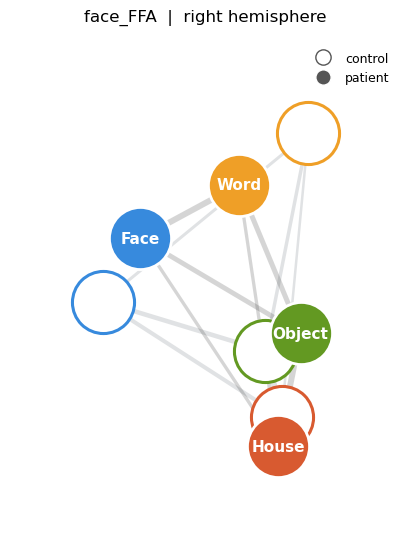

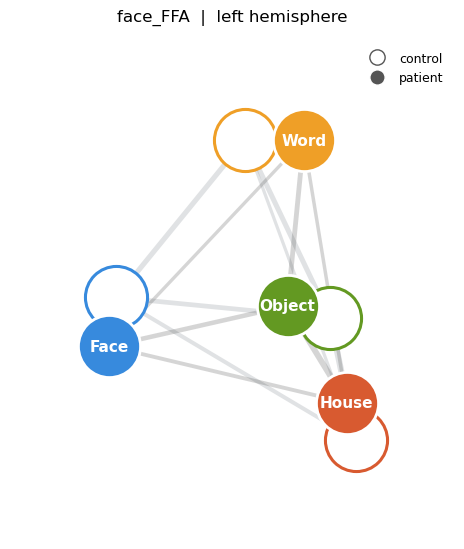

In [18]:
# ─── Procrustes/MDS configuration plots — selected ROI x hemi ────────────
PAIRS6 = [('face','object'),('face','house'),('face','word'),
          ('house','object'),('object','word'),('house','word')]

def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(coords(csim), coords(psim))
    return csim, psim, mtx1, mtx2

def plot_procrustes(roi, hemi):
    s = stratum(df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        return
    csim, psim, c_xy, p_xy = out
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i,0], c_xy[j,0]], [c_xy[i,1], c_xy[j,1]], color='#9aa0a6',
                lw=0.4 + r*5.5, alpha=0.30, solid_capstyle='round', zorder=1)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i,0], p_xy[j,0]], [p_xy[i,1], p_xy[j,1]], color='#444',
                lw=0.4 + r*5.5, alpha=0.22, solid_capstyle='round', zorder=2)
    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)
    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere', fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:,0].min()-pad, allxy[:,0].max()+pad)
    ax.set_ylim(allxy[:,1].min()-pad, allxy[:,1].max()+pad)
    legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

SELECTED = [("word_VWFA", "r"), ("face_FFA", "r"), ("face_FFA", "l")]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)